In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf
import statsmodels.api as sm
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [21]:
end = dt.date.today()
start = end - dt.timedelta(365)
df = yf.download(["^NSEI", "^NSEBANK"], start=start, end=end, auto_adjust=True)['Close']
df.rename(columns = {'^NSEBANK':'bank','^NSEI':'nse',}, inplace = True)

# Creating Returns
returns = df.pct_change().dropna()
x = returns['nse']
y = returns['bank']


[*********************100%***********************]  2 of 2 completed


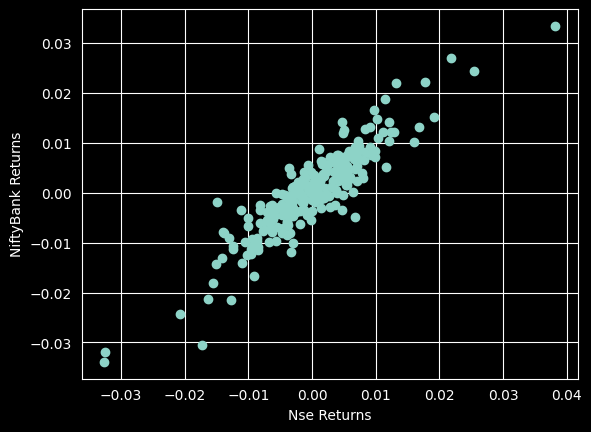

In [22]:
# Scatter Plot
plt.scatter(x,y)
plt.xlabel('Nse Returns')
plt.ylabel("NiftyBank Returns")
plt.show()

In [23]:
# Correlation
corr = x.corr(y)
print(corr)

0.9074073759267798


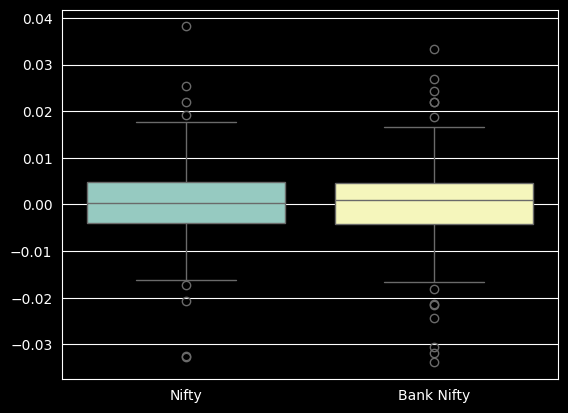

In [24]:
# Outlier Check
sns.boxplot(data=[x,y])
plt.xticks([0,1],['Nifty','Bank Nifty'])
plt.show()

In [25]:
# outlier Check
from scipy.stats import zscore

z_x = pd.Series(zscore(x),index= x.index)
z_y = pd.Series(zscore(y),index= y.index)

outliers = (z_x.abs() > 3) | (z_y.abs() > 3)

print("Outliers:\n", returns[outliers])

Outliers:
 Ticker          bank       nse
Date                          
2025-04-07 -0.031893 -0.032433
2025-04-15  0.027002  0.021902
2025-05-12  0.033354  0.038183
2026-02-03  0.024263  0.025476
2026-03-09 -0.030518 -0.017276
2026-03-19 -0.033891 -0.032621


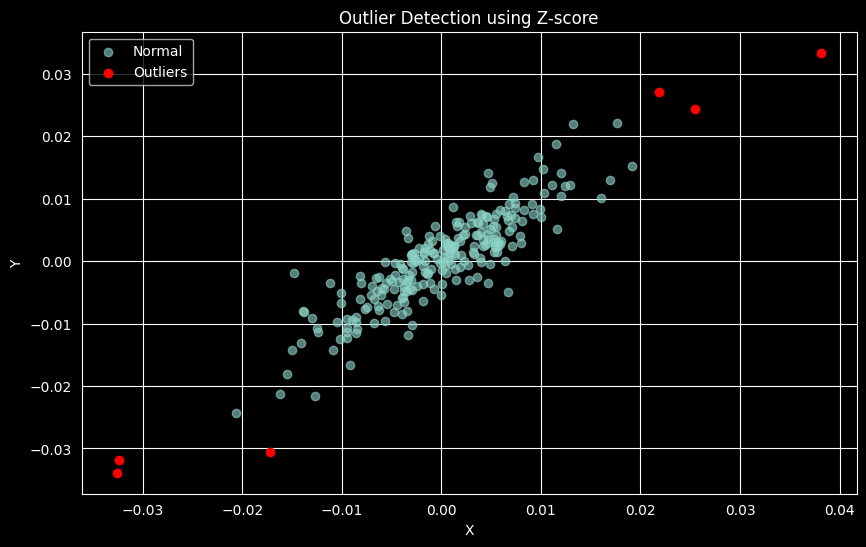

In [26]:
plt.figure(figsize=(10,6))

# Normal points
plt.scatter(x[~outliers], y[~outliers], label='Normal', alpha=0.6)

# Outliers
plt.scatter(x[outliers], y[outliers], color='red', label='Outliers')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Outlier Detection using Z-score')
plt.legend()

plt.show()

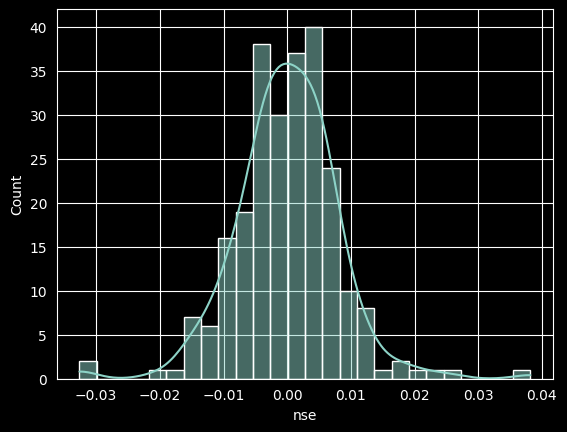

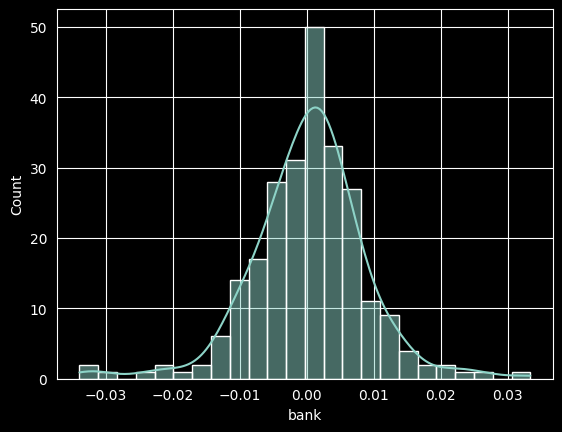

In [27]:
# Data Distribution
sns.histplot(x,kde=True)
plt.show()

sns.histplot(y,kde=True)
plt.show()

In [28]:
# Model Training
x = sm.add_constant(x)
model = sm.OLS(y,x).fit()
residuals = model.resid
print(residuals)

Date
2025-03-24    0.008860
2025-03-25   -0.002567
2025-03-26   -0.000520
2025-03-27    0.002540
2025-03-28    0.002515
                ...   
2026-03-16    0.001090
2026-03-17    0.001066
2026-03-18   -0.000185
2026-03-19   -0.002400
2026-03-20   -0.005471
Length: 246, dtype: float64


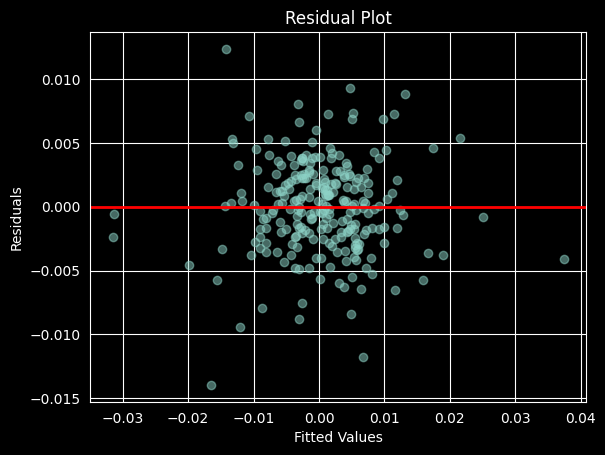

In [29]:
# Residual Plotting

plt.scatter(model.fittedvalues, residuals, alpha=0.5)
plt.axhline(y=0, color='red',linewidth='2')


plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

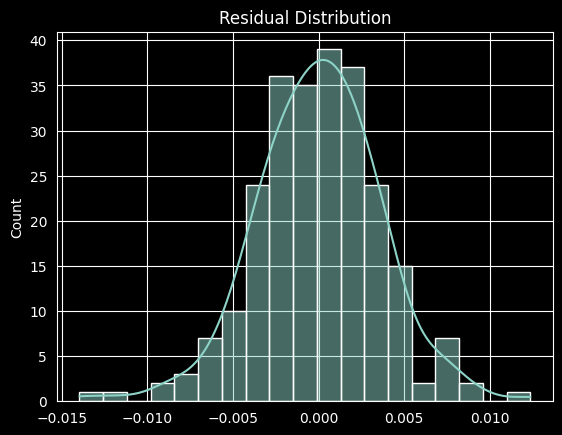

In [30]:
# Residual Distirbution

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

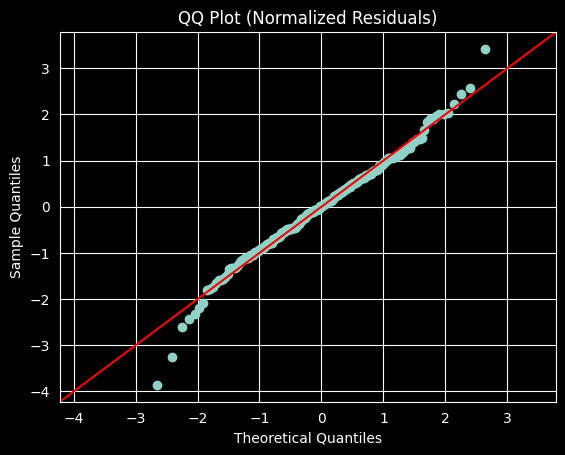

In [31]:
# Normalized  Residual qqplot
sm.qqplot(residuals,fit=True ,line='45')
plt.title("QQ Plot (Normalized Residuals)")
plt.show()

In [32]:
# Print the regression results summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   bank   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     1138.
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           7.69e-94
Time:                        18:55:26   Log-Likelihood:                 1033.9
No. Observations:                 246   AIC:                            -2064.
Df Residuals:                     244   BIC:                            -2057.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      1.155      0.2

In [33]:
print("Dependent Variable → What we are predicting (Y): Bank Nifty Returns")
print("Independent Variable → What drives prediction (X): Nifty Returns")
alpha = model.params.iloc[0]
print(f"Alpha: {alpha} → Extra return when market is 0 (stock-specific return)")
beta = model.params.iloc[1]
print(f"Beta: {beta} → Reliance moves {beta}x of NSE (market sensitivity)")
p_value = model.pvalues.iloc[1]
print(f"P-value: {p_value} → {'Significant (real relationship)' if p_value < 0.05 else 'Not significant (random)'}")
t_stat = model.tvalues.iloc[1]
print(f"T-stat: {t_stat} → Strength of signal (higher = stronger)")
std_err = model.bse.iloc[1]
print(f"Standard Error: {std_err} → Uncertainty in beta (lower = more reliable)")
r2 = model.rsquared
print(f"R²: {r2} → {r2*100:.2f}% of Reliance movement explained by NSE")
adj_r2 = model.rsquared_adj
print(f"Adjusted R²: {adj_r2} → True explanatory power (penalized version)")
f_stat = model.fvalue
print(f"F-statistic: {f_stat} → Overall model usefulness")
f_pval = model.f_pvalue
print(f"F-test p-value: {f_pval} → {'Model is valid' if f_pval < 0.05 else 'Model not useful'}")
mae = np.mean(np.abs(residuals))
print(f"MAE: {mae} → Average prediction error")
rmse = np.sqrt(np.mean(residuals**2))
print(f"RMSE: {rmse} → Typical prediction error (penalizes large errors)")
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print(f"Durbin-Watson: {dw} → {'No autocorrelation' if 1.8 < dw < 2.2 else 'Autocorrelation present'}")
skew = residuals.skew()
print(f"Skewness: {skew} → {'Symmetric distribution' if abs(skew)<0.5 else 'Skewed distribution'}")
kurt = residuals.kurtosis()
print(f"Kurtosis: {kurt} → {'Fat tails (extreme moves likely)' if kurt>3 else 'Normal tails'}")
from scipy.stats import jarque_bera
jb_stat, jb_p = jarque_bera(residuals)

print(f"Jarque-Bera p-value: {jb_p} → {'Normal distribution' if jb_p>0.05 else 'Not normal'}")

Dependent Variable → What we are predicting (Y): Bank Nifty Returns
Independent Variable → What drives prediction (X): Nifty Returns
Alpha: 0.0002674999867556508 → Extra return when market is 0 (stock-specific return)
Beta: 0.9735563284229142 → Reliance moves 0.9735563284229142x of NSE (market sensitivity)
P-value: 7.69204289246231e-94 → Significant (real relationship)
T-stat: 33.727744041552434 → Strength of signal (higher = stronger)
Standard Error: 0.028865148146982406 → Uncertainty in beta (lower = more reliable)
R²: 0.8233881458863228 → 82.34% of Reliance movement explained by NSE
Adjusted R²: 0.8226643268120865 → True explanatory power (penalized version)
F-statistic: 1137.560718132476 → Overall model usefulness
F-test p-value: 7.692042892462151e-94 → Model is valid
MAE: 0.00278561358827282 → Average prediction error
RMSE: 0.003618586642664216 → Typical prediction error (penalizes large errors)
Durbin-Watson: 1.8055034823340448 → No autocorrelation
Skewness: -0.1800925535144406 →

Text(0.5, 1.0, 'Simple Linear Regression')

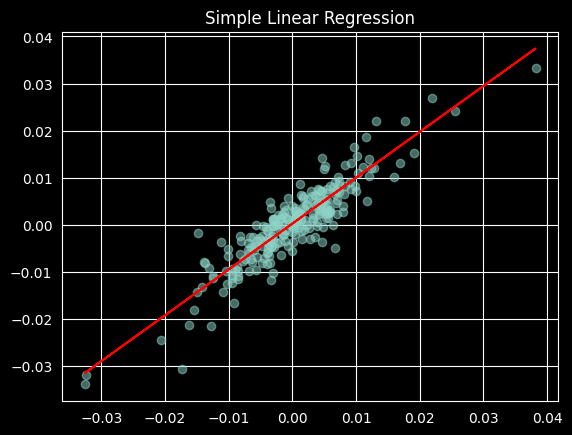

In [34]:
# Plotting
plt.scatter(returns['nse'], returns['bank'],alpha=0.5)
plt.plot(returns['nse'],model.fittedvalues,color = 'red',label = 'regression line')
plt.title('Simple Linear Regression')